In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,cross_val_score,StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import optuna as op
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,ConfusionMatrixDisplay,roc_auc_score

In [3]:
data = pd.read_csv("../data/Dataset.csv")
df = pd.read_csv("../data/processed.csv")
new_df = pd.read_csv("../data/Optimized.csv")

In [4]:
data["TotalCharges"] = data["TotalCharges"].replace(" ", np.nan)
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"])
data.dropna(subset=["TotalCharges"], inplace=True)
data = data.drop(["customerID"],axis=1)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

In [5]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])
df.dropna(subset=["TotalCharges"], inplace=True)
df = df.drop(["customerID"],axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   SeniorCitizen       7032 non-null   int64  
 1   Partner             7032 non-null   object 
 2   Dependents          7032 non-null   object 
 3   tenure              7032 non-null   int64  
 4   PhoneService        7032 non-null   object 
 5   InternetService     7032 non-null   object 
 6   OnlineSecurity      7032 non-null   object 
 7   OnlineBackup        7032 non-null   object 
 8   DeviceProtection    7032 non-null   object 
 9   TechSupport         7032 non-null   object 
 10  Contract            7032 non-null   object 
 11  PaperlessBilling    7032 non-null   object 
 12  PaymentMethod       7032 non-null   object 
 13  MonthlyCharges      7032 non-null   float64
 14  TotalCharges        7032 non-null   float64
 15  Churn               7032 non-null   object 
 16  familytype 

In [7]:
new_df["TotalCharges"] = new_df["TotalCharges"].replace(" ", np.nan)
new_df["TotalCharges"] = pd.to_numeric(new_df["TotalCharges"])
new_df.dropna(subset=["TotalCharges"], inplace=True)
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   SeniorCitizen       7032 non-null   int64  
 1   PhoneService        7032 non-null   object 
 2   MultipleLines       7032 non-null   object 
 3   InternetService     7032 non-null   object 
 4   PaymentMethod       7032 non-null   object 
 5   MonthlyCharges      7032 non-null   float64
 6   TotalCharges        7032 non-null   float64
 7   Churn               7032 non-null   object 
 8   familytype          7032 non-null   object 
 9   SecurityScore       7032 non-null   int64  
 10  EntertainmentScore  7032 non-null   int64  
 11  Customertype        7032 non-null   object 
dtypes: float64(2), int64(3), object(7)
memory usage: 714.2+ KB


In [8]:
df["TotalCharges"].describe()

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64

In [293]:
X1 = data.drop("Churn",axis=1)
y1 = data["Churn"].map({"Yes":1,"No":0})
X2 = df.drop("Churn",axis=1)
y2 = df["Churn"].map({"Yes":1,"No":0})
X3 = new_df.drop("Churn",axis=1)
y3 = new_df["Churn"].map({"Yes":1,"No":0})

In [294]:
num_cols1 = X1.select_dtypes(include=["number"]).columns.tolist()
cat_cols1 = X1.select_dtypes(include=["object","string"]).columns.tolist()
num_cols2 = X2.select_dtypes(include=["number"]).columns.tolist()
cat_cols2 = X2.select_dtypes(include=["object","string"]).columns.tolist()
num_cols3 = X3.select_dtypes(include=["number"]).columns.tolist()
cat_cols3 = X3.select_dtypes(include=["object","string"]).columns.tolist()

In [295]:
X_temp1, X_test1, y_temp1, y_test1 = train_test_split(
    X1,
    y1,
    test_size=0.20,
    random_state=42,
    stratify=y1
)
X_train1, X_val1, y_train1, y_val1 = train_test_split(
    X_temp1,
    y_temp1,
    test_size=0.25,
    random_state=42,
    stratify=y_temp1
)
X_temp2, X_test2, y_temp2, y_test2 = train_test_split(
    X2,
    y2,
    test_size=0.20,
    random_state=42,
    stratify=y2
)
X_train2, X_val2, y_train2, y_val2 = train_test_split(
    X_temp2,
    y_temp2,
    test_size=0.25,
    random_state=42,
    stratify=y_temp2
)
X_temp3, X_test3, y_temp3, y_test3 = train_test_split(
    X3,
    y3,
    test_size=0.20,
    random_state=42,
    stratify=y3
)
X_train3, X_val3, y_train3, y_val3 = train_test_split(
    X_temp3,
    y_temp3,
    test_size=0.25,
    random_state=42,
    stratify=y_temp3
)

In [296]:
transformer1 = ColumnTransformer(transformers=[
    ("num_trans","passthrough",num_cols1),
    ("cat_trans",OneHotEncoder(handle_unknown="ignore",sparse_output=False),cat_cols1)
],remainder="passthrough").set_output(transform="pandas")
transformer2 = ColumnTransformer(transformers=[
    ("num_trans","passthrough",num_cols2),
    ("cat_trans",OneHotEncoder(sparse_output=False,handle_unknown="ignore"),cat_cols2)
],remainder="passthrough").set_output(transform="pandas")
transformer3 = ColumnTransformer(transformers=[
    ("num_trans","passthrough",num_cols3),
    ("cat_trans",OneHotEncoder(sparse_output=False,handle_unknown="ignore"),cat_cols3)
],remainder="passthrough").set_output(transform="pandas")


In [298]:
def objective(trial):
    classifier = trial.suggest_categorical("classifier",["lr","rf","xgbc"])
    if classifier == "lr":
       C = trial.suggest_float("C",0.1,100,log=True)
       lr_solver_penalty = trial.suggest_categorical("lr_solver_penalty",["liblinear_l1","liblinear_l2","saga_l1","saga_l2","saga_elasticnet","newton_cholesky_l2"])
       if lr_solver_penalty == "liblinear_l1":
            solver = "liblinear"
            penalty = "l1"
       elif lr_solver_penalty == "liblinear_l2":
            solver = "liblinear"
            penalty = "l2"
       elif lr_solver_penalty == "saga_l1":
            solver = "saga"
            penalty = "l1"
       elif lr_solver_penalty == "saga_l2":
            solver = "saga"
            penalty = "l2"
       elif lr_solver_penalty == "saga_elasticnet":
            solver = "saga"
            penalty = "elasticnet"
       elif lr_solver_penalty == "newton_cholesky_l2":
        solver = "newton-cholesky"
        penalty = "l2"
       if penalty == "elasticnet":
            lr_l1_ratio = trial.suggest_float("lr_l1_ratio",0.0,1.0)
       else:
            lr_l1_ratio = None
       max_iter = trial.suggest_int("max_iter",100,1000)
       class_weight = trial.suggest_categorical("lr_class_weight",[None, "balanced"])
       model = LogisticRegression(C=C,penalty=penalty,solver=solver,random_state=42,class_weight=class_weight,n_jobs=-1,max_iter=max_iter)
    elif classifier == "rf":
        n_estimators = trial.suggest_int("n_estimators",5,300)
        max_depth = trial.suggest_int("max_depth",3,20)
        min_samples_split = trial.suggest_int("min_samples_split",2,10)
        min_samples_leaf = trial.suggest_int("min_samples_leaf",1,10)
        bootstrap = trial.suggest_categorical("bootstrap",[True,False])
        class_weight = trial.suggest_categorical("rf_class_weight",[None, "balanced", "balanced_subsample"])
        model = RandomForestClassifier(n_estimators=n_estimators,max_depth=max_depth,min_samples_split=min_samples_split,min_samples_leaf=min_samples_leaf,bootstrap=bootstrap,n_jobs=-1,class_weight=class_weight)
    else:
        n_estimators = trial.suggest_int("n_estimators", 100, 1000)
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
        max_depth = trial.suggest_int("max_depth", 3, 10)
        min_child_weight = trial.suggest_int("min_child_weight", 1, 10)
        xgb_gamma = trial.suggest_float("xgb_gamma", 0, 5)
        subsample = trial.suggest_float("subsample", 0.6, 1.0)
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0)
        reg_alpha = trial.suggest_float("reg_alpha", 1e-8, 10, log=True)
        reg_lambda = trial.suggest_float("reg_lambda", 1e-8, 10, log=True)
        scale_pos_weight = trial.suggest_float("scale_pos_weight",1.0,10.0)
        model = XGBClassifier(objective="binary:logistic",eval_metric="logloss",n_estimators=n_estimators,learning_rate=learning_rate,max_depth=max_depth,min_child_weight=min_child_weight,gamma=xgb_gamma,subsample=subsample,colsample_bytree=colsample_bytree,reg_alpha=reg_alpha,reg_lambda=reg_lambda,n_jobs=-1,scale_pos_weight=scale_pos_weight)
    dataset = trial.suggest_categorical("dataset",["original", "engineered", "reduced_engineered"])
    if dataset == "original":
        X = X_train1
        y = y_train1
        pipeline = Pipeline([
            ("preprocessing",transformer1),
            ("model",model)
        ])
    elif dataset == "engineered":
        X = X_train2
        y = y_train2
        pipeline = Pipeline([
                    ("preprocessing",transformer2),
                    ("model",model)
                ])
    else:
        X = X_train3
        y = y_train3
        pipeline = Pipeline([
                    ("preprocessing",transformer3),
                    ("model",model)
                ])
    score = cross_val_score(pipeline,X,y,cv=3,scoring="recall",n_jobs=-1).mean()
    return score

In [299]:
study = op.create_study(direction="maximize")
study.optimize(objective,n_trials=150,n_jobs=-1)
best_trial = study.best_trial
print(best_trial)
print(best_trial.params)
print(best_trial.value)

[I 2026-08-11 15:40:30,943] A new study created in memory with name: no-name-956fc5b6-77b7-4d8e-bcf7-a3951284b74e
[I 2026-08-11 15:40:51,426] Trial 1 finished with value: 0.5191944679407224 and parameters: {'classifier': 'rf', 'n_estimators': 34, 'max_depth': 11, 'min_samples_split': 5, 'min_samples_leaf': 6, 'bootstrap': False, 'rf_class_weight': None, 'dataset': 'original'}. Best is trial 1 with value: 0.5191944679407224.
[I 2026-08-11 15:40:52,092] Trial 0 finished with value: 0.0 and parameters: {'classifier': 'rf', 'n_estimators': 53, 'max_depth': 10, 'min_samples_split': 7, 'min_samples_leaf': 10, 'bootstrap': True, 'rf_class_weight': None, 'dataset': 'reduced_engineered'}. Best is trial 1 with value: 0.5191944679407224.
[I 2026-08-11 15:40:52,292] Trial 8 finished with value: 0.8099501560312158 and parameters: {'classifier': 'lr', 'C': 2.3327255670319005, 'lr_solver_penalty': 'newton_cholesky_l2', 'max_iter': 159, 'lr_class_weight': 'balanced', 'dataset': 'original'}. Best is tr

FrozenTrial(number=71, state=<TrialState.COMPLETE: 1>, values=[0.9330977333658299], datetime_start=datetime.datetime(2026, 8, 11, 15, 45, 6, 362617), datetime_complete=datetime.datetime(2026, 8, 11, 15, 48, 1, 785383), params={'classifier': 'xgbc', 'n_estimators': 642, 'learning_rate': 0.014772429517208379, 'max_depth': 3, 'min_child_weight': 7, 'xgb_gamma': 4.30887988630369, 'subsample': 0.9345010381687457, 'colsample_bytree': 0.7845716464011531, 'reg_alpha': 0.6018483658794248, 'reg_lambda': 0.9646874054921434, 'scale_pos_weight': 9.057434056212632, 'dataset': 'reduced_engineered'}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'classifier': CategoricalDistribution(choices=('lr', 'rf', 'xgbc')), 'n_estimators': IntDistribution(high=1000, log=False, low=100, step=1), 'learning_rate': FloatDistribution(high=0.3, log=True, low=0.01, step=None), 'max_depth': IntDistribution(high=10, log=False, low=3, step=1), 'min_child_weight': IntDistribution(high=10, log=False

In [300]:
def objective(trial):
        n_estimators = trial.suggest_int("n_estimators", 100, 1000)
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
        max_depth = trial.suggest_int("max_depth", 3, 10)
        min_child_weight = trial.suggest_int("min_child_weight", 1, 10)
        gamma = trial.suggest_float("gamma", 0, 5)
        subsample = trial.suggest_float("subsample", 0.6, 1.0)
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0)
        reg_alpha = trial.suggest_float("reg_alpha", 1e-8, 10, log=True)
        reg_lambda = trial.suggest_float("reg_lambda", 1e-8, 10, log=True)
        scale_pos_weight = trial.suggest_float("scale_pos_weight",1.0,10.0)
        model = XGBClassifier(objective="binary:logistic",eval_metric="logloss",n_estimators=n_estimators,learning_rate=learning_rate,max_depth=max_depth,min_child_weight=min_child_weight,gamma=gamma,subsample=subsample,colsample_bytree=colsample_bytree,reg_alpha=reg_alpha,reg_lambda=reg_lambda,n_jobs=-1,scale_pos_weight=scale_pos_weight,random_state=42)
        pipeline = Pipeline([
                ("preprocessor",transformer1),
                ("model",model)])
        score = cross_val_score(pipeline,X_train1,y_train1,cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42),scoring="recall",n_jobs=1).mean()
        return score

In [301]:
sampler = op.samplers.TPESampler(seed=42)
study = op.create_study(direction="maximize",sampler=sampler)
study.optimize(objective,n_trials=150,n_jobs=1)
best_trial = study.best_trial
print(best_trial)
print(best_trial.params)
print(best_trial.value)
best_params = study.best_params

[I 2026-08-11 15:51:29,955] A new study created in memory with name: no-name-5e37a672-1a1b-4330-a356-c612cd420318
[I 2026-08-11 15:51:32,303] Trial 0 finished with value: 0.6735079365079365 and parameters: {'n_estimators': 437, 'learning_rate': 0.2536999076681772, 'max_depth': 8, 'min_child_weight': 6, 'gamma': 0.7800932022121826, 'subsample': 0.662397808134481, 'colsample_bytree': 0.6232334448672797, 'reg_alpha': 0.6245760287469893, 'reg_lambda': 0.002570603566117598, 'scale_pos_weight': 7.372653200164409}. Best is trial 0 with value: 0.6735079365079365.
[I 2026-08-11 15:51:33,305] Trial 1 finished with value: 0.6422857142857142 and parameters: {'n_estimators': 118, 'learning_rate': 0.2708160864249968, 'max_depth': 9, 'min_child_weight': 3, 'gamma': 0.9091248360355031, 'subsample': 0.6733618039413735, 'colsample_bytree': 0.7216968971838151, 'reg_alpha': 0.00052821153945323, 'reg_lambda': 7.71800699380605e-05, 'scale_pos_weight': 3.6210622617823773}. Best is trial 0 with value: 0.67350

FrozenTrial(number=123, state=<TrialState.COMPLETE: 1>, values=[0.9696587301587302], datetime_start=datetime.datetime(2026, 8, 11, 15, 55, 16, 655162), datetime_complete=datetime.datetime(2026, 8, 11, 15, 55, 17, 809259), params={'n_estimators': 100, 'learning_rate': 0.010766400392664653, 'max_depth': 4, 'min_child_weight': 3, 'gamma': 0.32842511091625193, 'subsample': 0.6940041390954559, 'colsample_bytree': 0.7995079379372055, 'reg_alpha': 3.088051724043825e-06, 'reg_lambda': 5.41963436686926e-08, 'scale_pos_weight': 9.752760424385832}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=1000, log=False, low=100, step=1), 'learning_rate': FloatDistribution(high=0.3, log=True, low=0.01, step=None), 'max_depth': IntDistribution(high=10, log=False, low=3, step=1), 'min_child_weight': IntDistribution(high=10, log=False, low=1, step=1), 'gamma': FloatDistribution(high=5.0, log=False, low=0.0, step=None), 'subsample': FloatDistribution

In [302]:
pipeline1 = Pipeline([
    ("preprocessor",transformer1),
    ("model",XGBClassifier(**best_params,objective="binary:logistic",eval_metric="logloss",random_state=42,n_jobs=-1))
])

In [303]:
pipeline1.fit(X_train1,y_train1)
y_val_pred1 = pipeline1.predict(X_val1)
y_val_proba1 = pipeline1.predict_proba(X_val1)[:, 1]

In [304]:
thresholds = np.arange(0.10,0.91,0.01)
results = []
for threshold in thresholds:
    y_val_pred1 = ( y_val_proba1 >= threshold).astype(int)
    precision = precision_score(y_val1,y_val_pred1,zero_division=0)
    recall = recall_score(y_val1,y_val_pred1,zero_division=0)
    f1 = f1_score(y_val1,y_val_pred1,zero_division=0)
    results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })
threshold_results = pd.DataFrame(results)
minimum_precision = 0.50
eligible = threshold_results[threshold_results["precision"] >= minimum_precision]
best_row = eligible.loc[eligible["recall"].idxmax()]
best_threshold = best_row["threshold"]
print("Selected threshold:", best_threshold)

Selected threshold: 0.7499999999999997


Accuracy: 74.13%
Precision: 50.84%
Recall: 80.75%
F1: 62.40%
ROC-AUC: 83.12%


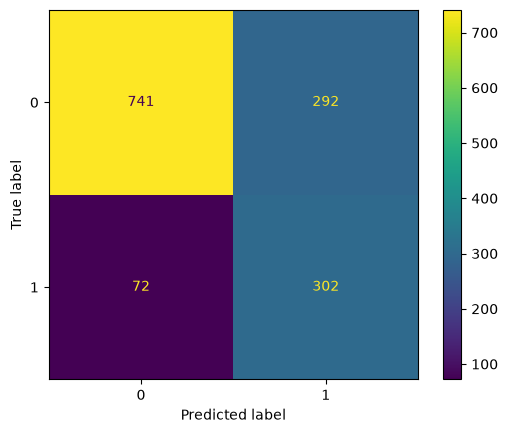

In [276]:
y_test_proba1 = pipeline1.predict_proba(X_test1)[:, 1]
y_test_pred1 = (y_test_proba1 >= best_threshold).astype(int)
print(f"Accuracy: "f"{accuracy_score(y_test1, y_test_pred1)*100:.2f}%")
print(f"Precision: "f"{precision_score(y_test1, y_test_pred1)*100:.2f}%")
print(f"Recall: "f"{recall_score(y_test1, y_test_pred1)*100:.2f}%")
print(f"F1: "f"{f1_score(y_test1, y_test_pred1)*100:.2f}%")
print(f"ROC-AUC: "f"{roc_auc_score(y_test1, y_test_proba1)*100:.2f}%")
ConfusionMatrixDisplay.from_predictions(y_test1,y_test_pred1)
plt.show()

In [305]:
def objective(trial):
        n_estimators = trial.suggest_int("n_estimators", 100, 1000)
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
        max_depth = trial.suggest_int("max_depth", 3, 10)
        min_child_weight = trial.suggest_int("min_child_weight", 1, 10)
        gamma = trial.suggest_float("gamma", 0, 5)
        subsample = trial.suggest_float("subsample", 0.6, 1.0)
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0)
        reg_alpha = trial.suggest_float("reg_alpha", 1e-8, 10, log=True)
        reg_lambda = trial.suggest_float("reg_lambda", 1e-8, 10, log=True)
        scale_pos_weight = trial.suggest_float("scale_pos_weight",1.0,10.0)
        model = XGBClassifier(objective="binary:logistic",eval_metric="logloss",n_estimators=n_estimators,learning_rate=learning_rate,max_depth=max_depth,min_child_weight=min_child_weight,gamma=gamma,subsample=subsample,colsample_bytree=colsample_bytree,reg_alpha=reg_alpha,reg_lambda=reg_lambda,n_jobs=-1,scale_pos_weight=scale_pos_weight,random_state=42)
        pipeline = Pipeline([
                ("preprocessor",transformer2),
                ("model",model)])
        score = cross_val_score(pipeline,X_train2,y_train2,cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42),scoring="recall",n_jobs=1).mean()
        return score

In [306]:
sampler = op.samplers.TPESampler(seed=42)
study = op.create_study(direction="maximize",sampler=sampler)
study.optimize(objective,n_trials=150,n_jobs=1)
best_trial = study.best_trial
print(best_trial)
print(best_trial.params)
print(best_trial.value)
best_params = study.best_params

[I 2026-08-11 15:58:04,468] A new study created in memory with name: no-name-174ed8db-d32a-477a-b7be-2026f4c32bb0
[I 2026-08-11 15:58:06,589] Trial 0 finished with value: 0.6770634920634919 and parameters: {'n_estimators': 437, 'learning_rate': 0.2536999076681772, 'max_depth': 8, 'min_child_weight': 6, 'gamma': 0.7800932022121826, 'subsample': 0.662397808134481, 'colsample_bytree': 0.6232334448672797, 'reg_alpha': 0.6245760287469893, 'reg_lambda': 0.002570603566117598, 'scale_pos_weight': 7.372653200164409}. Best is trial 0 with value: 0.6770634920634919.
[I 2026-08-11 15:58:07,505] Trial 1 finished with value: 0.6458690476190476 and parameters: {'n_estimators': 118, 'learning_rate': 0.2708160864249968, 'max_depth': 9, 'min_child_weight': 3, 'gamma': 0.9091248360355031, 'subsample': 0.6733618039413735, 'colsample_bytree': 0.7216968971838151, 'reg_alpha': 0.00052821153945323, 'reg_lambda': 7.71800699380605e-05, 'scale_pos_weight': 3.6210622617823773}. Best is trial 0 with value: 0.67706

FrozenTrial(number=80, state=<TrialState.COMPLETE: 1>, values=[0.9660873015873017], datetime_start=datetime.datetime(2026, 8, 11, 16, 1, 27, 231488), datetime_complete=datetime.datetime(2026, 8, 11, 16, 1, 28, 652044), params={'n_estimators': 100, 'learning_rate': 0.010135741504846071, 'max_depth': 5, 'min_child_weight': 10, 'gamma': 2.1767206092334814, 'subsample': 0.8639688151739384, 'colsample_bytree': 0.6184420428439027, 'reg_alpha': 8.517451253173012e-08, 'reg_lambda': 2.922504089966854e-08, 'scale_pos_weight': 9.111395831318026}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=1000, log=False, low=100, step=1), 'learning_rate': FloatDistribution(high=0.3, log=True, low=0.01, step=None), 'max_depth': IntDistribution(high=10, log=False, low=3, step=1), 'min_child_weight': IntDistribution(high=10, log=False, low=1, step=1), 'gamma': FloatDistribution(high=5.0, log=False, low=0.0, step=None), 'subsample': FloatDistribution(h

In [307]:
pipeline2 = Pipeline([
    ("preprocessor",transformer2),
    ("model",XGBClassifier(**best_params,objective="binary:logistic",eval_metric="logloss",random_state=42,n_jobs=-1))
])

In [308]:
pipeline2.fit(X_train2,y_train2)
y_val_pred2 = pipeline2.predict(X_val2)
y_val_proba2 = pipeline2.predict_proba(X_val2)[:, 1]

In [309]:
thresholds = np.arange(0.10,0.91,0.01)
results = []
for threshold in thresholds:
    y_val_pred2 = ( y_val_proba2 >= threshold).astype(int)
    precision = precision_score(y_val2,y_val_pred2,zero_division=0)
    recall = recall_score(y_val2,y_val_pred2,zero_division=0)
    f1 = f1_score(y_val2,y_val_pred2,zero_division=0)
    results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })
threshold_results = pd.DataFrame(results)
minimum_precision = 0.50
eligible = threshold_results[threshold_results["precision"] >= minimum_precision]
best_row = eligible.loc[eligible["recall"].idxmax()]
best_threshold = best_row["threshold"]
print("Selected threshold:", best_threshold)

Selected threshold: 0.7199999999999996


Accuracy: 74.77%
Precision: 51.64%
Recall: 80.21%
F1: 62.83%
ROC-AUC: 83.21%


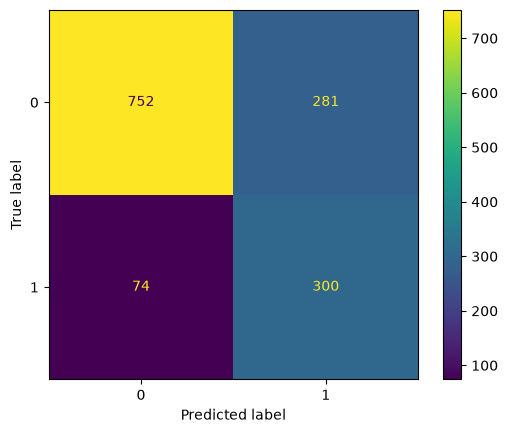

In [282]:
y_test_proba2 = pipeline2.predict_proba(X_test2)[:, 1]
y_test_pred2 = (y_test_proba2 >= best_threshold).astype(int)
print(f"Accuracy: "f"{accuracy_score(y_test2, y_test_pred2)*100:.2f}%")
print(f"Precision: "f"{precision_score(y_test2, y_test_pred2)*100:.2f}%")
print(f"Recall: "f"{recall_score(y_test2, y_test_pred2)*100:.2f}%")
print(f"F1: "f"{f1_score(y_test2, y_test_pred2)*100:.2f}%")
print(f"ROC-AUC: "f"{roc_auc_score(y_test2, y_test_proba2)*100:.2f}%")
ConfusionMatrixDisplay.from_predictions(y_test2,y_test_pred2)
plt.show()

In [310]:
def objective(trial):
        n_estimators = trial.suggest_int("n_estimators", 100, 1000)
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
        max_depth = trial.suggest_int("max_depth", 3, 10)
        min_child_weight = trial.suggest_int("min_child_weight", 1, 10)
        gamma = trial.suggest_float("gamma", 0, 5)
        subsample = trial.suggest_float("subsample", 0.6, 1.0)
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0)
        reg_alpha = trial.suggest_float("reg_alpha", 1e-8, 10, log=True)
        reg_lambda = trial.suggest_float("reg_lambda", 1e-8, 10, log=True)
        scale_pos_weight = trial.suggest_float("scale_pos_weight",1.0,10.0)
        model = XGBClassifier(objective="binary:logistic",eval_metric="logloss",n_estimators=n_estimators,learning_rate=learning_rate,max_depth=max_depth,min_child_weight=min_child_weight,gamma=gamma,subsample=subsample,colsample_bytree=colsample_bytree,reg_alpha=reg_alpha,reg_lambda=reg_lambda,n_jobs=-1,scale_pos_weight=scale_pos_weight,random_state=42)
        pipeline = Pipeline([
                ("preprocessor",transformer3),
                ("model",model)])
        score = cross_val_score(pipeline,X_train3,y_train3,cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42),scoring="recall",n_jobs=1).mean()
        return score

In [311]:
sampler = op.samplers.TPESampler(seed=42)
study = op.create_study(direction="maximize",sampler=sampler)
study.optimize(objective,n_trials=150,n_jobs=1)
best_trial = study.best_trial
print(best_trial)
print(best_trial.params)
print(best_trial.value)
best_params = study.best_params

[I 2026-08-11 16:03:57,794] A new study created in memory with name: no-name-42e9fc2f-1bb8-48a3-97e9-3fd54e6155b2
[I 2026-08-11 16:05:07,794] Trial 0 finished with value: 0.689531746031746 and parameters: {'n_estimators': 437, 'learning_rate': 0.2536999076681772, 'max_depth': 8, 'min_child_weight': 6, 'gamma': 0.7800932022121826, 'subsample': 0.662397808134481, 'colsample_bytree': 0.6232334448672797, 'reg_alpha': 0.6245760287469893, 'reg_lambda': 0.002570603566117598, 'scale_pos_weight': 7.372653200164409}. Best is trial 0 with value: 0.689531746031746.
[I 2026-08-11 16:05:34,180] Trial 1 finished with value: 0.6333690476190477 and parameters: {'n_estimators': 118, 'learning_rate': 0.2708160864249968, 'max_depth': 9, 'min_child_weight': 3, 'gamma': 0.9091248360355031, 'subsample': 0.6733618039413735, 'colsample_bytree': 0.7216968971838151, 'reg_alpha': 0.00052821153945323, 'reg_lambda': 7.71800699380605e-05, 'scale_pos_weight': 3.6210622617823773}. Best is trial 0 with value: 0.6895317

FrozenTrial(number=149, state=<TrialState.COMPLETE: 1>, values=[0.9580873015873015], datetime_start=datetime.datetime(2026, 8, 11, 18, 22, 53, 57339), datetime_complete=datetime.datetime(2026, 8, 11, 18, 23, 18, 345335), params={'n_estimators': 146, 'learning_rate': 0.01168887743799789, 'max_depth': 3, 'min_child_weight': 9, 'gamma': 4.681173379474009, 'subsample': 0.9343063033222554, 'colsample_bytree': 0.8070555752482427, 'reg_alpha': 8.545968962839758e-06, 'reg_lambda': 0.05838920348119093, 'scale_pos_weight': 9.997711777042698}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=1000, log=False, low=100, step=1), 'learning_rate': FloatDistribution(high=0.3, log=True, low=0.01, step=None), 'max_depth': IntDistribution(high=10, log=False, low=3, step=1), 'min_child_weight': IntDistribution(high=10, log=False, low=1, step=1), 'gamma': FloatDistribution(high=5.0, log=False, low=0.0, step=None), 'subsample': FloatDistribution(high

In [312]:
pipeline3 = Pipeline([
    ("preprocessor",transformer3),
    ("model",XGBClassifier(**best_params,objective="binary:logistic",
      eval_metric="logloss",random_state=42,n_jobs=-1))
    ])

In [313]:
pipeline3.fit(X_train3,y_train3)
y_pred3 = pipeline3.predict(X_test3)
y_val_proba3 = pipeline3.predict_proba(X_val3)[:, 1]

In [314]:
thresholds = np.arange(0.10,0.91,0.01)
results = []
minimum_precision = 0.50
for threshold in thresholds:
    y_val_pred3 = ( y_val_proba3 >= threshold).astype(int)
    precision = precision_score(y_val3,y_val_pred3,zero_division=0)
    recall = recall_score(y_val3,y_val_pred3,zero_division=0)
    f1 = f1_score(y_val3,y_val_pred3,zero_division=0)
    results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })
threshold_results = pd.DataFrame(results)
minimum_precision = 0.50
eligible = threshold_results[threshold_results["precision"] >= minimum_precision]
best_row = eligible.loc[eligible["recall"].idxmax()]
best_threshold = best_row["threshold"]
print("Selected threshold:", best_threshold)

Selected threshold: 0.7599999999999997


Accuracy: 73.17%
Precision: 49.65%
Recall: 76.74%
F1: 60.29%
ROC-AUC: 81.83%


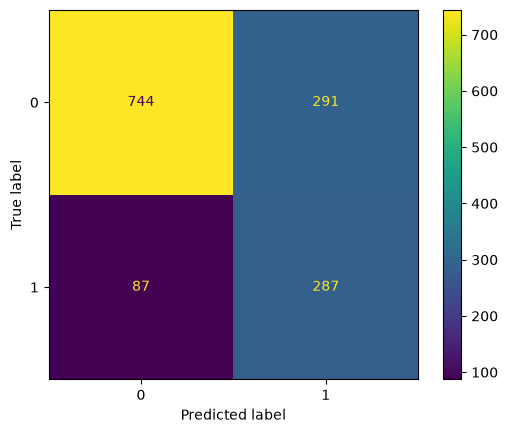

In [315]:
y_test_proba3 = pipeline3.predict_proba(X_test3)[:, 1]
y_test_pred3 = (y_test_proba3 >= best_threshold).astype(int)
print(f"Accuracy: "f"{accuracy_score(y_test3, y_test_pred3)*100:.2f}%")
print(f"Precision: "f"{precision_score(y_test3, y_test_pred3)*100:.2f}%")
print(f"Recall: "f"{recall_score(y_test3, y_test_pred3)*100:.2f}%")
print(f"F1: "f"{f1_score(y_test3, y_test_pred3)*100:.2f}%")
print(f"ROC-AUC: "f"{roc_auc_score(y_test3, y_test_proba3)*100:.2f}%")
ConfusionMatrixDisplay.from_predictions(y_test3,y_test_pred3)
plt.show()